### Upload Files to Colab

To upload files from your local system to your Colab environment, you can use the `files.upload()` function. This will open a widget that allows you to select files from your computer.

In [4]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_csv("netflix_titles.csv")
print(df.shape)
print(df.head())


Saving netflix_titles.csv to netflix_titles (1).csv
(8807, 12)
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021  

In [5]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [13]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df = df.dropna(subset=["date_added", "rating"])

print(df.shape)
print(df.isnull().sum())

(8793, 14)
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
year_added      0
genres          0
dtype: int64


In [16]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["year_added"] = df["date_added"].dt.year
df["genres"] = df["listed_in"].str.split(", ")

print(df[["date_added", "year_added", "genres"]].head())

  date_added  year_added                                             genres
0 2021-09-25        2021                                    [Documentaries]
1 2021-09-24        2021  [International TV Shows, TV Dramas, TV Mysteries]
2 2021-09-24        2021  [Crime TV Shows, International TV Shows, TV Ac...
3 2021-09-24        2021                           [Docuseries, Reality TV]
4 2021-09-24        2021  [International TV Shows, Romantic TV Shows, TV...


In [17]:
type_counts = df["type"].value_counts()
print(type_counts)
print("Movie %:", round(type_counts.get("Movie", 0) / len(df) * 100, 1))
print("TV Show %:", round(type_counts.get("TV Show", 0) / len(df) * 100, 1))

type
Movie      6129
TV Show    2664
Name: count, dtype: int64
Movie %: 69.7
TV Show %: 30.3


In [18]:
all_genres = df.explode("genres")["genres"].str.strip()
top_genres = all_genres.value_counts().head(10)
print(top_genres)

genres
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


In [19]:
yearly = df.groupby("year_added")["show_id"].count()
print(yearly)

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     428
2017    1186
2018    1648
2019    2016
2020    1879
2021    1498
Name: show_id, dtype: int64


In [20]:
top_countries = df["country"].value_counts().head(10)
print(top_countries)

country
United States     2812
India              972
Unknown            829
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


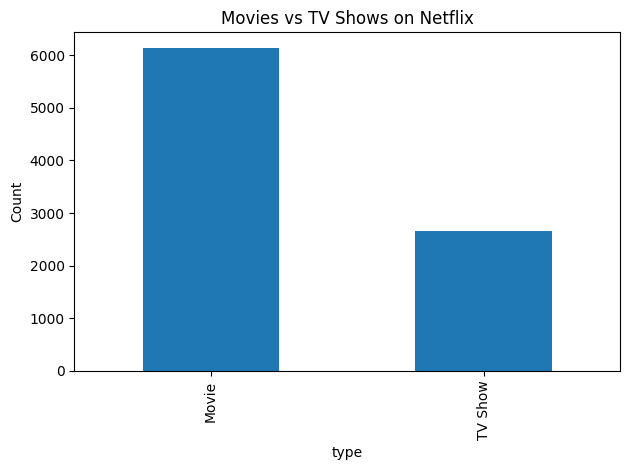

In [21]:
import matplotlib.pyplot as plt

type_counts.plot(kind="bar", title="Movies vs TV Shows on Netflix")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("movies_vs_tvshows.png")
plt.show()

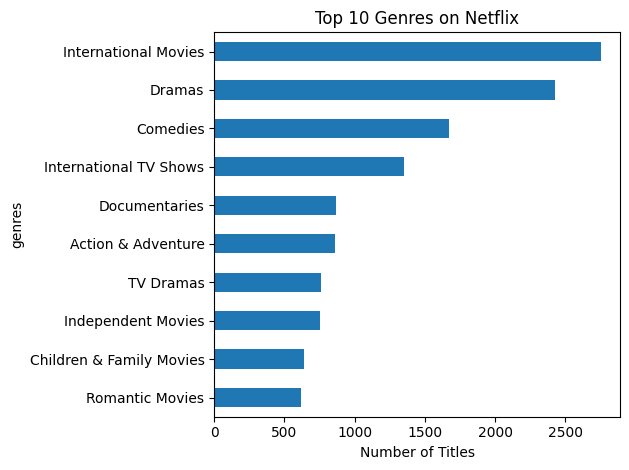

In [22]:
top_genres.plot(kind="barh", title="Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("top_genres.png")
plt.show()

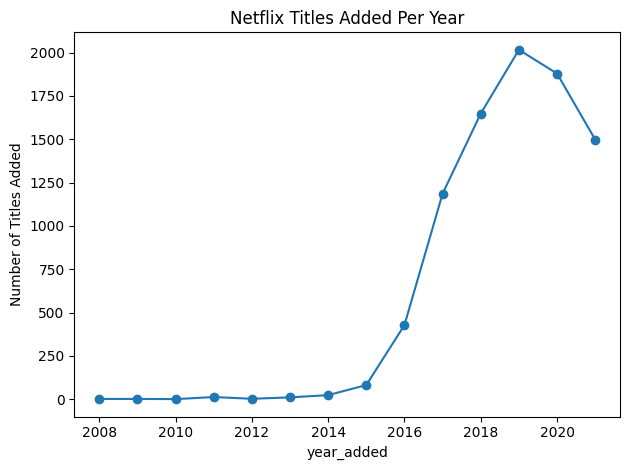

In [23]:
yearly.plot(kind="line", marker="o", title="Netflix Titles Added Per Year")
plt.ylabel("Number of Titles Added")
plt.tight_layout()
plt.savefig("titles_per_year.png")
plt.show()

### Accessing Uploaded Files

Once files are uploaded, you can access them by their filenames. For example, to read a CSV file using pandas:

```python
import pandas as pd

# Assuming you uploaded a file named 'my_data.csv'
df = pd.read_csv('my_data.csv')
display(df.head())
```